# Implement the whole evaluation pipeline for Llama 3.1 8B

Load fine tunned Llama 3.1. 8B 


1) Iterate through the best solutions extracted (integrated pareto front, data in the image). For each solution compute

      1.1) UQ with compute_hdbscan_KNN(...)

      1.2) Repeat N times the evaluation process 
        - Build a fresh eval_df2 = make_calib_eval_split(...) for that repetition
        - Run the threshold schemes
          B30 R30, B30 R10, B25 R10
          and save tau values too

    1.3) Summarize across repetitions with mean, var, std
   
3) Summarize across solutions with mean, var, std

Two levels of summarization

Level 1 per solution
For each solution in the integrated Pareto set, compute UQ once, then repeat the calibration split N times, evaluate B30 R30, B30 R10, B25 R10 each time, store tau_bert and tau_rouge, then compute mean, var, std across the N repeats.

Level 2 across solutions
After computed per solution summaries, aggregate mean, var, std across all solutions, per model and per scheme.

SCHEMES = {
    "B30 R30": (30, 30),
    "B30 R10": (30, 20),
    "B25 R10": (25, 10),
}
COVERAGES = (0.8, 0.9, 0.95, 1.0)

In [1]:
import re
import unicodedata
from typing import Iterable, List, Optional, Sequence, Tuple, Union, Dict, Any
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.stats import pearsonr

import pandas as pd
from scipy.stats import pearsonr
from dataclasses import dataclass
import ast
import json
from scipy.stats import spearmanr

import numpy as np
import torch
from scipy.spatial.distance import cdist
from rouge_score import rouge_scorer

# Ragas
import os
from openai import AsyncOpenAI
from datasets import Dataset
from ragas import evaluate
from ragas.metrics.collections import answer_correctness
from ragas.embeddings import OpenAIEmbeddings
from ragas.llms import InstructorLLM
from concurrent.futures import ThreadPoolExecutor

import asyncio
from ragas.llms import llm_factory
from ragas.metrics.collections import Faithfulness
from __future__ import annotations

# Optional but recommended if you want to cap statement count
from ragas.metrics.collections.faithfulness.util import StatementGeneratorPrompt
from transformers import GenerationConfig

# utilities 
from utility_kde_clustering_optimization import *

/home/mmora/Applications/anaconda3/envs/ragas_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
### Helpers functions 
#-------------------------------------------------------------------------------------------------------
def load_model_and_tokenizer_4bits(model_name):
    """
    Loads a pre-trained LLaMA 3.1 8B model and tokenizer with 4-bit quantization.
    :params:
    - model_name (str): The name or path of the pre-trained LLaMA model from the Hugging Face Model Hub.

    :returns:
    - model: The loaded LLaMA model with 4-bit quantization and adjustments for fine-tuning.
    - tokenizer: The corresponding tokenizer for the loaded model.
  """
    # Configuration for 4-bit quantization
    bnb_config = BitsAndBytesConfig(
       load_in_4bit=True,
       bnb_4bit_quant_type="nf4",
       bnb_4bit_use_double_quant=True,
       bnb_4bit_compute_dtype=torch.bfloat16,
    )
    #attn_implementation is sugested by the model card https://huggingface.co/docs/transformers/model_doc/llama3
    #computes attention in blocks and avoid excessive memory usage, especially in models with long sequences.
    #attn_implementation="flash_attention_2"
    attn_implementation = "eager"

    # Load the model with 8-bit quantization
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        attn_implementation=attn_implementation,
        trust_remote_code=True,
        device_map={"": 0},          # pin everything to GPU 0, avoids model.to()
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    """
    use_cache = False is recommended during fine-tuning to save memory and avoid unnecessary caching of hidden states.
    # model.config.use_cache = False  #  default = True https://huggingface.co/docs/transformers/model_doc/llama2
    """
    model.config.use_cache = False
    tokenizer.padding_side = 'right' 

    return model, tokenizer

def data_for_experiment(root_folder_path,
                          num_samples,num_samples_testing,num_samples_distant,layer_embedding):
    """
    Prepare data for experiments. Randomly select data  (test, train, d01 and d02), generate embeddings for train data.

    return:
        eval_df: evala data (concat of test, d01 and d02)
        train_sentence_embeddings.
    """
    # randomly select samples 
    train_samples_df, test_samples_df, dist01_samples_df, dist02_samples_df = load_data_random(root_folder_path,
                          num_samples,num_samples_testing,num_samples_distant,layer_embedding)     

    # concat eval data
    
    test_block = (
       test_samples_df[["question", "test_best_answers", "test_model_answers", "bertscore_f1", "meteor_evals"]]
       .rename(columns={"test_best_answers": "answer", "test_model_answers": "model_answer"})
    )
    test_block["split"] = "test"

    d01_block = (
       dist01_samples_df[["question", "distant_true_answers", "distant_model_answers", "bertscore_f1", "meteor_evals"]]
       .rename(columns={"distant_true_answers": "answer", "distant_model_answers": "model_answer"})
    )
    d01_block["split"] = "d01"

    d02_block = (
       dist02_samples_df[["question", "distant_true_answers", "distant_model_answers", "bertscore_f1", "meteor_evals"]]
       .rename(columns={"distant_true_answers": "answer", "distant_model_answers": "model_answer"})
    )
    d02_block["split"] = "d02"

    eval_df = pd.concat([test_block, d01_block, d02_block], ignore_index=True)
    
    return train_samples_df,  eval_df


#-----------------------------------------------------------------
# Preprocess data
def to_text(x):
    # Handles NaN, None, floats, etc.
    if x is None:
        return ""
    # pandas NaN is float and != itself
    try:
        if isinstance(x, float) and (x != x):
            return ""
    except Exception:
        pass
    return str(x)
    

def compute_rougeL_per_sample(predictions, references, use_stemmer=True):

    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=use_stemmer)
    scores = []

    for pred, ref in zip(predictions, references):
        pred_txt = to_text(pred)
        ref_txt = to_text(ref)

        s = scorer.score(ref_txt, pred_txt)
        scores.append(float(s["rougeL"].fmeasure))

    return scores
    
#-------------------------------------------------------------------
def precompute_train_embeddings(train_samples_df, model, tokenizer, device, answer_length):
    """
    Compute embbedings to create the cluster model.
    """
    emb = generate_embeddings_simple(
        train_samples_df,
        model,
        tokenizer,
        device,
        EMB_LAYER_FIXED,
        answer_length,
        TRAIN_COL,
    )
    return np.asarray(emb)

#############################################################################
#---------------------------------- Preprocess text ------------------
def _clean_whitespace(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def _to_text(x: Any) -> str:
    """
    Convert model_answer into a single string.
    Handles:
      - list or tuple: joins items with newlines
      - string that looks like a list literal: parses and joins
      - None: empty string
    """
    if x is None:
        return ""

    # If the cell is already a list (common in pandas)
    if isinstance(x, (list, tuple)):
        parts = [str(p) for p in x if p is not None]
        return "\n".join(parts)

    s = str(x)

    # If it's a string representation of a list, try to parse
    t = s.strip()
    if t.startswith("[") and t.endswith("]"):
        # JSON first
        try:
            obj = json.loads(t)
            if isinstance(obj, list):
                return "\n".join(str(p) for p in obj if p is not None)
        except Exception:
            pass
        # Python literal fallback
        try:
            obj = ast.literal_eval(t)
            if isinstance(obj, list):
                return "\n".join(str(p) for p in obj if p is not None)
        except Exception:
            pass

    return s

def _strip_wrappers(s: str) -> str:
    # 
    s = re.sub(r"<\|\s*begin_of_text\s*\|>", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"<\|\s*end_of_text\s*\|>", " ", s, flags=re.IGNORECASE)
    return s

def _strip_leading_prompt_blocks(s: str, max_passes: int = 3) -> str:
    """
    Repeatedly remove a leading:
      prompt: ... completion: ...
    If completion: is missing, remove only the first prompt: line.
    """
    out = s
    for _ in range(max_passes):
        out = _strip_wrappers(out).lstrip()

        if not re.match(r"(?i)^prompt\s*:", out):
            break

        if re.search(r"(?i)\bcompletion\s*:", out):
            out = re.sub(
                r"(?is)^prompt\s*:.*?\bcompletion\s*:\s*",
                "",
                out,
                count=1,
            )
        else:
            out = re.sub(
                r"(?im)^prompt\s*:\s*[^\r\n]*\r?\n?",
                "",
                out,
                count=1,
            )

    return out

def normalize_record(question: str, true_answer: str, model_answer: Any) -> str:
    q = _clean_whitespace(str(question))
    _ = _clean_whitespace(str(true_answer))  # kept for signature symmetry

    ma = _to_text(model_answer)
    ma = _strip_wrappers(ma)

    # Remove leading prompt blocks robustly (and idempotently)
    ma = _strip_leading_prompt_blocks(ma, max_passes=5)

    # If completion label remains anywhere, drop only the label
    ma = re.sub(r"(?i)\bcompletion\s*:\s*", "", ma)

    # If the question is still literally repeated at the start, remove it once
    q_esc = re.escape(q)
    ma = re.sub(rf"(?i)^\s*(?:in medicine:\s*)?{q_esc}\s*", "", ma, count=1)

    return _clean_whitespace(ma)

def normalize_records(
    questions,
    true_answers,
    model_answers,
) -> List[str]:
    qs = list(questions)
    tas = list(true_answers)
    mas = list(model_answers)

    if len(qs) != len(tas) or len(qs) != len(mas):
        raise ValueError(f"Length mismatch: {len(qs)=}, {len(tas)=}, {len(mas)=}")

    return [normalize_record(q, ta, ma) for q, ta, ma in zip(qs, tas, mas)]

def concatenate_columns_to_list(df, col1, col2, sep=" "):
    """
    Concatenate two columns of a DataFrame row-wise and return the result as a list.

   Returns
    -------
    list
        A list where each element is the concatenation of col1 and col2
        for the corresponding row.
    """
    return (df[col1].astype(str) + sep + df[col2].astype(str)).tolist()
    

In [4]:
#== Load fine tunned Llama 3.1. 8B 
based_model_name = "meta-llama/Llama-3.1-8B"
model_name = "mariamoracrossitcr/Llama-3.1-8B-medquad-V2"

model_name_tokenizer = "meta-llama/Llama-3.1-8B"
model_short_name = 'Llama-3.1-8B-medquad'
answer_length = 200 
device = "cuda" if torch.cuda.is_available() else "cpu"

model, tokenizer = load_model_and_tokenizer_4bits( model_name)


Loading checkpoint shards: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.87s/it]


In [6]:
# Variables 
#### ------------------------------------------------

EMB_LAYER_FIXED = 32
#TRAIN_COL = "train_model_answers"
TRAIN_COL = 'train_best_answers'
EVAL_COL = "model_answer_cleaned"
Data_PATH = "/home/mmora/Documents/Models/LLM_KerelDensityEstimation/UQ_KDE y Clustering(completo antes del BIP-2025)/experimentos/ExperimentoFinalMuestras/"

num_samples = 5000
num_samples_testing = 600
num_samples_distant = 35
layer_embedding = "tscaling/"
reduction_method = 'PCA'
#DIMENSIONALITY = 128

#### ------------------------------------------------
EMB_DIM_CHOICES = [128, 256, 512, 1024]
REDUCTION_CHOICES = ["PCA"]

VAR_NAMES = [
    "hdb_min_cluster_size",
    "hdb_min_samples",
    "hdb_epsilon",
    "knn_min_samples",
    "emb_dim_index",
    "red_index",
]

INT_COLS = {0, 1, 3, 4, 5}  # integer variables in X

#### ------------------------------------------------

# Variables and constants\
SCHEMES = {
    "B30 R30": (30, 30),
    "B30 R20": (30, 20),
    "B25 R10": (25, 20),
    "B30 R0":  (30, 0),
    "B0 R30":  (0, 30),
    
}
COVERAGES = (0.8, 0.9, 0.95, 1.0)

In [7]:
## Read and clean data for the experiment
train_samples_df, eval_df = data_for_experiment(
        Data_PATH, num_samples, num_samples_testing, num_samples_distant, layer_embedding
    )

# clean model answers
eval_df["model_answer"] = eval_df["model_answer"].astype("object")
eval_df["answer"] = eval_df["answer"].astype("object")
predictions = eval_df["model_answer"].tolist()
references = eval_df["answer"].tolist()

predictions = normalize_records(eval_df["question"].tolist(), eval_df["answer"].tolist(), eval_df["model_answer"].tolist())
# Add a column with the cleaned answers
eval_df["model_answer_cleaned"] = predictions

# compute rouge for test, D01, D02
eval_df["rougeL"] = compute_rougeL_per_sample(predictions, references, use_stemmer=False)



In [8]:
print(eval_df.columns)

Index(['question', 'answer', 'model_answer', 'bertscore_f1', 'meteor_evals',
       'split', 'model_answer_cleaned', 'rougeL'],
      dtype='object')


In [9]:
print(train_samples_df[TRAIN_COL])

13013    Summary : A1C is a blood test for type 2 diabe...
11177    PXE is inherited in an autosomal recessive man...
13602    Complex regional pain syndrome (CRPS) is a chr...
1160     Muscle relaxing drugs such as baclofen, diazep...
5831     What are the signs and symptoms of Familial mi...
                               ...                        
1917     Summary : It seems to happen almost every day ...
10320    TAR syndrome is characterized by the absence o...
11182    Creutzfeldt-Jakob disease (CJD) is a rare, deg...
4984     Myosin storage myopathy is a rare condition. I...
3442     What are the signs and symptoms of Accessory d...
Name: train_best_answers, Length: 5000, dtype: object


In [10]:
# print records to compare results
pd.set_option("display.max_colwidth", None)   # avoid truncation in pandas displays
pd.set_option("display.width", 200)           # optional

x = eval_df["model_answer_cleaned"].iloc[59]           # first record

# If the cell is a list like ["<|begin_of_text|>prompt: ..."]
if isinstance(x, list) and len(x) > 0:
    x = x[0]

print(x)            # full text
print("\nrepr:\n")  # useful to see \n, quotes, etc
print(repr(x))

Sitosterolemia is caused by mutations in the ABCG5 and ABCG8 genes. These genes provide instructions for making proteins that are part of a transporter called a sterol transporter. Sterols are a type of fat that is important for the normal structure and function of cell membranes. Sterols also play a role in the production of steroid hormones, which are produced by the adrenal glands, gonads, and other tissues. Sterols are found in animal products such as meat and dairy products and in vegetable oils. The ABCG5 and ABCG8 proteins work together (cooperate) to form the sterol transporter. This transporter is found in the cell membrane of intestinal cells, liver cells, and cells in the gallbladder and kidneys. The transporter moves cholesterol and plant sterols from inside the cell to the cell membrane, where they can be incorporated into bile. Bile is a digestive fluid that is released from the liver and stored in the gallbladder. Bile contains

repr:

'Sitosterolemia is caused by mutati

In [11]:
print(train_samples_df.columns)

Index(['train_questions_id', 'train_model_answers', 'train_best_answers', 'train_questions'], dtype='object')


In [12]:
# Add question to answers

TRAIN_COL = 'train_best_answers'
EVAL_COL = "model_answer_cleaned"

train_samples_df['train_answers_with_question'] = concatenate_columns_to_list(train_samples_df, 'train_questions',TRAIN_COL, sep=" ")
eval_df['model_answer_cleaned_question'] = concatenate_columns_to_list(eval_df,'question',  EVAL_COL,  sep=" ")

TRAIN_COL = 'train_answers_with_question'
EVAL_COL = "model_answer_cleaned_question"


In [13]:
####
"""
Compute embeddings. 
It is a time consuming process
"""
###
train_sentence_embeddings = precompute_train_embeddings(
        train_samples_df, model, tokenizer, device, answer_length)


# Dentro de evaluate configuration
eval_embeddings = generate_embeddings_simple(
                    eval_df, model, tokenizer, device,
                    EMB_LAYER_FIXED, answer_length, EVAL_COL
                )
train_embeddings, eval_embeddings, scaler = standard_scaler_normalization_scaler(
                    train_sentence_embeddings, eval_embeddings
                )


---
# Run the whole pipeline with all repetitions
---

In [14]:
# Helpers

#
def _stats_1d(x):
    x = np.asarray(x, dtype=float)
    n = int(x.size)
    if n == 0:
        return {"n": 0, "mean": np.nan, "var": np.nan, "std": np.nan}
    if n == 1:
        return {"n": 1, "mean": float(x[0]), "var": np.nan, "std": np.nan}
    return {
        "n": n,
        "mean": float(np.mean(x)),
        "var": float(np.var(x, ddof=1)),
        "std": float(np.std(x, ddof=1)),
    }


def summarize_rep_results(per_rep_scheme_results, schemes=SCHEMES, coverages=COVERAGES):
    """
    per_rep_scheme_results is a list length N_repeats.
    Each element is a dict scheme_name -> result from evaluate_threshold_scheme.

    Returns a dict scheme_name -> summary stats for tau, auroc, aurc, rejection accuracy.
    """
    out = {}
    for scheme_name in schemes.keys():
        tau_b = [r[scheme_name]["tau_bert"] for r in per_rep_scheme_results]
        tau_r = [r[scheme_name]["tau_rouge"] for r in per_rep_scheme_results]
        auroc = [r[scheme_name]["auroc"] for r in per_rep_scheme_results]
        aurc = [r[scheme_name]["aurc"] for r in per_rep_scheme_results]
        acc_joint = [r[scheme_name]["acc_joint"] for r in per_rep_scheme_results]

        rej = {}
        for c in coverages:
            rej[c] = [r[scheme_name]["rejection_acc"][c] for r in per_rep_scheme_results]

        out[scheme_name] = {
            "tau_bert": _stats_1d(tau_b),
            "tau_rouge": _stats_1d(tau_r),
            "auroc": _stats_1d(auroc),
            "aurc": _stats_1d(aurc),
            "acc_joint": _stats_1d(acc_joint),
            "rejection_acc": {c: _stats_1d(rej[c]) for c in coverages},
        }
    return out

#### ------------------------------------Core step for one solution
"""
This matches step 1.1, 1.2, 1.3

Compute UQ once
Repeat evaluation N times, only split2 changes
Save raw repetition results and the summarization per scheme
"""
def evaluate_one_solution_with_repeated_calib(
    *,
    solution_params,
    train_data_reduced,
    eval_data_reduced,
    eval_df,
    n_repeats,
    split_seed_base=42,
    schemes=SCHEMES,
    coverages=COVERAGES,
    group_col="split",
    calib_from=("test",),
    calib_frac=0.30,
    split2_col="split2",
):
    """
    solution_params should contain:
      min_cluster_size, min_samples, cluster_selection_epsilon, n_neighbors

    Returns a dict with
      params
      uq optional summary
      rep_results_raw, list of N dicts of scheme results
      rep_results_summary, dict of scheme -> mean var std, includes tau stats
    """

    min_cluster_size = int(solution_params["min_cluster_size"])
    min_samples = int(solution_params["min_samples"])
    cluster_selection_epsilon = float(solution_params["cluster_selection_epsilon"])
    n_neighbors = int(solution_params["n_neighbors"])

    uq = compute_hdbscan_KNN(
        train_data_reduced,
        eval_data_reduced,
        min_cluster_size,
        min_samples,
        cluster_selection_epsilon,
        n_neighbors,
    )
    uq = np.asarray(uq, dtype=float)
    if uq.shape[0] != len(eval_df):
        raise ValueError(
            f"UQ length mismatch, got {uq.shape[0]} but eval_df has {len(eval_df)} rows"
        )

    per_rep_scheme_results = []

    for r in range(int(n_repeats)):
        seed_split = int(split_seed_base + r)

        eval_df2 = eval_df.copy()
        eval_df2["UQ"] = uq

        eval_df2 = make_calib_eval_split(
            eval_df2,
            group_col=group_col,
            calib_from=calib_from,
            calib_frac=calib_frac,
            seed=seed_split,
            split2_col=split2_col,
        )

        scheme_dict = {}
        for scheme_name, (p_bert, p_rouge) in schemes.items():
            scheme_dict[scheme_name] = evaluate_threshold_scheme(
                eval_df2,
                p_bert=p_bert,
                p_rouge=p_rouge,
                coverages=coverages,
            )

        per_rep_scheme_results.append(scheme_dict)

    rep_results_summary = summarize_rep_results(
        per_rep_scheme_results,
        schemes=schemes,
        coverages=coverages,
    )

    return {
        "params": solution_params,
        "uq_summary": _stats_1d(uq),
        "rep_results_raw": per_rep_scheme_results,
        "rep_results_summary": rep_results_summary,
    }


## ------ Loop over all solutions in the integrated Pareto set
"""
This matches your step 1 overall
"""

def run_all_solutions(
    df_best,
    train_embeddings, 
    eval_embeddings, 
    eval_df,
    n_repeats,
    split_seed_base=42,
    schemes=SCHEMES,
    coverages=COVERAGES,
):
    """
    df_best needs columns like your table:
      hdb_min_cluster_size, hdb_min_samples, hdb_epsilon, knn_min_samples
    """

    all_solutions = []
    for idx, row in df_best.iterrows():
        sol_params = {
            "solution_index": int(idx),
            "min_cluster_size": int(row["hdb_min_cluster_size"]),
            "min_samples": int(row["hdb_min_samples"]),
            "cluster_selection_epsilon": float(row["hdb_epsilon"]),
            "n_neighbors": int(row["knn_min_samples"]),
            "emb_dim": int(row["emb_dim"]) if "emb_dim" in row else None,
            "reduction": str(row["reduction"]) if "reduction" in row else None,
            "f1": float(row["f1"]) if "f1" in row else None,
            "f2": float(row["f2"]) if "f2" in row else None,
        }

        print(int(row["emb_dim"]) )
        train_data_reduced, eval_data_reduced, pca_instance = compute_pca(
                    train_embeddings, eval_embeddings, int(row["emb_dim"]) 
                )
        
        res = evaluate_one_solution_with_repeated_calib(
            solution_params=sol_params,
            train_data_reduced=train_data_reduced,
            eval_data_reduced=eval_data_reduced,
            eval_df=eval_df,
            n_repeats=n_repeats,
            split_seed_base=split_seed_base,
            schemes=schemes,
            coverages=coverages,
        )
        all_solutions.append(res)

    return all_solutions

##-------------------- Summarize across all solutions with mean, var, std
"""
This matches the step 2.

Important: at the solution level you already have mean AUROC etc across repeated calibration splits. 
Now we aggregate those means across solutions.

For each scheme and metric compute mean, var, std across solutions.
"""
def summarize_across_solutions(
    all_solutions_results,
    schemes=SCHEMES,
    coverages=COVERAGES,
):
    """
    all_solutions_results is output of run_all_solutions.

    Aggregates across solutions using each solution's mean over repeats.
    Returns stats across solutions.
    """
    out = {}

    for scheme_name in schemes.keys():
        auroc_means = []
        aurc_means = []
        acc_means = []
        tau_b_means = []
        tau_r_means = []
        rej_means = {c: [] for c in coverages}

        for sol in all_solutions_results:
            s = sol["rep_results_summary"][scheme_name]
            auroc_means.append(s["auroc"]["mean"])
            aurc_means.append(s["aurc"]["mean"])
            acc_means.append(s["acc_joint"]["mean"])
            tau_b_means.append(s["tau_bert"]["mean"])
            tau_r_means.append(s["tau_rouge"]["mean"])
            for c in coverages:
                rej_means[c].append(s["rejection_acc"][c]["mean"])

        out[scheme_name] = {
            "auroc_mean_over_solutions": _stats_1d(auroc_means),
            "aurc_mean_over_solutions": _stats_1d(aurc_means),
            "acc_joint_mean_over_solutions": _stats_1d(acc_means),
            "tau_bert_mean_over_solutions": _stats_1d(tau_b_means),
            "tau_rouge_mean_over_solutions": _stats_1d(tau_r_means),
            "rejection_acc_mean_over_solutions": {c: _stats_1d(rej_means[c]) for c in coverages},
            "n_solutions": int(len(all_solutions_results)),
        }

    return out


#------------------------------------------- Make the calibration split

import numpy as np


def make_calib_eval_split(
    eval_df,
    *,
    group_col="split",
    calib_from=("test",),
    calib_frac=0.30,
    seed=42,
    split2_col="split2",
    calib_label="calib",
    eval_label="eval",
):
    """
    Create a calibration split inside eval_df for percentile thresholds.

    Why
    Strategy 1 needs thresholds computed on a calibration split, not on the same rows you evaluate on.

    What it does
    Only rows with eval_df[group_col] in calib_from are eligible for calibration.
    From those eligible rows, it randomly selects calib_frac to label as calibration.
    Everything else is labeled as evaluation.

    Typical use in your setup
    group_col = "split" has values like: "test", "D01", "D02"
    calib_from = ("test",) so calibration uses only in distribution rows
    D01 and D02 remain evaluation only

    Parameters
    eval_df : pd.DataFrame
        Your dataframe.
    group_col : str
        Column that indicates source group, default "split".
    calib_from : tuple[str]
        Groups allowed to contribute calibration rows, default ("test",).
    calib_frac : float
        Fraction of eligible rows used for calibration, default 0.30.
    seed : int
        Random seed for reproducibility.
    split2_col : str
        New column name to store "calib" or "eval".
    calib_label, eval_label : str
        Labels written into split2_col.

    Returns
    df_out : pd.DataFrame
        Copy of eval_df with split2_col added.
    """
    df_out = eval_df.copy()

    eligible_mask = df_out[group_col].isin(calib_from)
    eligible_idx = df_out.index[eligible_mask].to_numpy()

    rng = np.random.default_rng(seed)
    rng.shuffle(eligible_idx)

    n_calib = int(round(calib_frac * len(eligible_idx)))
    calib_idx = eligible_idx[:n_calib]

    df_out[split2_col] = eval_label
    df_out.loc[calib_idx, split2_col] = calib_label

    return df_out

#### ----------------------------evaluate_threshold_scheme
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def compute_thresholds(df_calib, p_bert, p_rouge):
    """
    Compute percentile thresholds on the calibration split. 
    Example: If p_bert = 25, this returns the value such that 25% of the calibration 
             samples have BERTScore ≤ this value, and 75% are above it.

    Parameters
    df_calib : pd.DataFrame
        Calibration rows only.
    p_bert : float
        Percentile for BERTScore threshold.
    p_rouge : float
        Percentile for ROUGE L threshold.

    Returns
    tau_bert, tau_rouge : float
    """
    tau_bert = float(np.percentile(df_calib["bertscore_f1"].values, p_bert))
    tau_rouge = float(np.percentile(df_calib["rougeL"].values, p_rouge))
    return tau_bert, tau_rouge


def joint_labels(df_eval, tau_bert, tau_rouge):
    """
    Joint correctness labels using AND rule:
      correct = (BERT >= tau_bert) AND (ROUGE >= tau_rouge)

    Returns
    y_correct : np.ndarray of int
    """
    return (
        (df_eval["bertscore_f1"].values >= tau_bert)
        & (df_eval["rougeL"].values >= tau_rouge)
    ).astype(int)


def auroc_for_uq(df_eval, y_correct):
    """
    AUROC where positive class is incorrect.
    Score is UQ.
    """
    y_error = 1 - y_correct
    return float(roc_auc_score(y_error, df_eval["UQ"].values.astype(float)))


def risk_coverage_and_aurc(df_eval, y_correct):
    """
    Risk coverage curve and AURC using UQ for abstention.
    """
    uq = df_eval["UQ"].values.astype(float)
    y_error = 1 - y_correct

    order = np.argsort(-uq)  # most uncertain first
    y_error_sorted = y_error[order]
    n = len(y_error_sorted)

    cum_err_from_end = np.cumsum(y_error_sorted[::-1])[::-1]

    coverage = np.empty(n, float)
    risk = np.empty(n, float)
    for k in range(n):
        kept = n - k
        coverage[k] = kept / n
        risk[k] = cum_err_from_end[k] / kept

    x = coverage[::-1]
    y = risk[::-1]
    if hasattr(np, "trapezoid"):
        aurc = float(np.trapezoid(y, x))
    else:
        dx = x[1:] - x[:-1]
        aurc = float(np.sum(0.5 * (y[1:] + y[:-1]) * dx))

    return coverage, risk, aurc


def rejection_accuracy(df_eval, y_correct, coverage):
    """
    Accuracy among kept samples when keeping a fixed coverage fraction.

    We keep the least uncertain samples.
    """
    uq = df_eval["UQ"].values.astype(float)
    order = np.argsort(uq)  # least uncertain first
    n = len(order)
    k_keep = int(np.ceil(coverage * n))
    keep_idx = order[:k_keep]
    return float(np.mean(y_correct[keep_idx]))


def evaluate_threshold_scheme(eval_df2, p_bert, p_rouge, coverages=(0.8, 0.9, 0.95, 1.0)):
    """
    Evaluate one (p_bert, p_rouge) scheme end to end.

    Calibration is eval_df2[split2 == "calib"]
    Evaluation is  eval_df2[split2 == "eval"]
    """
    df_calib = eval_df2[eval_df2["split2"] == "calib"]
    df_eval = eval_df2[eval_df2["split2"] == "eval"]

    tau_bert, tau_rouge = compute_thresholds(df_calib, p_bert, p_rouge)
    y_correct = joint_labels(df_eval, tau_bert, tau_rouge)

    auroc = auroc_for_uq(df_eval, y_correct)
    cov_curve, risk_curve, aurc = risk_coverage_and_aurc(df_eval, y_correct)

    rej_acc = {c: rejection_accuracy(df_eval, y_correct, c) for c in coverages}

    return {
        "p_bert": p_bert,
        "p_rouge": p_rouge,
        "tau_bert": tau_bert,
        "tau_rouge": tau_rouge,
        "acc_joint": float(y_correct.mean()),
        "err_joint": float(1 - y_correct.mean()),
        "auroc": auroc,
        "aurc": aurc,
        "rejection_acc": rej_acc,
        "coverage_curve": cov_curve,
        "risk_curve": risk_curve,
    }



---
Extract the integrated pareto front
---


In [15]:
###You can pass df_best like in your screenshot. It will evaluate every row as a solution.
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np


from __future__ import annotations

import os
import re
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


def _natural_key(s: str) -> list[Any]:
    import re as _re
    return [int(t) if t.isdigit() else t.lower() for t in _re.split(r"(\d+)", s)]


def _load_front_npz(npz_path: str) -> dict[str, Any]:
    d = np.load(npz_path, allow_pickle=False)
    return {k: d[k] for k in d.files}


def _nondominated_2obj(F: np.ndarray) -> np.ndarray:
    """
    Correct nondominated filter for 2 objectives, minimization.
    Sort by f1 ascending; keep points that achieve a new minimum in f2.
    """
    if F.ndim != 2 or F.shape[1] != 2:
        raise ValueError(f"_nondominated_2obj expects shape (n,2), got {F.shape}")

    idx = np.argsort(F[:, 0], kind="mergesort")
    Fs = F[idx]

    best_f2 = np.inf
    nd_sorted = np.zeros(len(Fs), dtype=bool)
    for i in range(len(Fs)):
        if Fs[i, 1] <= best_f2:
            best_f2 = Fs[i, 1]
            nd_sorted[i] = True

    nd = np.zeros(len(F), dtype=bool)
    nd[idx] = nd_sorted
    return nd


def get_cumulative_best_solutions(
    front_dir: str,
    *,
    x_key: str = "X",                  # if your npz contains decision variables
    decimals: int = 12,                # rounding for stable dedup
    return_unique_pool: bool = False,  # optionally return all unique solutions too
    plot: bool = False,                # quick plot of best line only
):
    """
    Return ONLY the cumulative best (final cumulative nondominated) solutions.

    Outputs:
      - cum_best_F: (k,2) objectives on the cumulative best front, sorted by f1
      - cum_best_X: (k,n_var) configs for those solutions, or None if X not present
    """
    front_dir_path = Path(front_dir)
    if not front_dir_path.exists():
        raise FileNotFoundError(f"front_dir does not exist: {front_dir}")

    files = [
        p for p in front_dir_path.iterdir()
        if p.is_file() and p.suffix == ".npz" and p.name.startswith("front_gen_")
    ]
    if not files:
        raise FileNotFoundError(f"No front_gen_*.npz found in: {front_dir}")

    files = sorted(files, key=lambda p: _natural_key(p.name))

    Fs = []
    Xs = []
    have_X = None

    for p in files:
        d = _load_front_npz(str(p))
        if "F" not in d:
            raise KeyError(f"File missing 'F': {p}")

        F = np.asarray(d["F"], dtype=float)
        if F.ndim != 2 or F.shape[1] != 2:
            raise ValueError(f"'F' must be shape (n,2). Got {F.shape} in {p}")
        Fs.append(F)

        this_has_X = (x_key in d)
        if have_X is None:
            have_X = this_has_X
        if have_X != this_has_X:
            raise ValueError(f"Inconsistent '{x_key}' presence across files. Example: {p}")

        if this_has_X:
            X = np.asarray(d[x_key], dtype=float)
            if X.ndim != 2 or X.shape[0] != F.shape[0]:
                raise ValueError(f"'{x_key}' must align with F rows. X {X.shape} vs F {F.shape} in {p}")
            Xs.append(X)

    all_F = np.vstack(Fs)
    all_X = np.vstack(Xs) if have_X else None

    # Deduplicate stably. If X exists, dedup on (F,X) so different configs with same F are preserved.
    if all_X is not None:
        combo = np.hstack([np.round(all_F, decimals), np.round(all_X, decimals)])
        _, uniq_idx = np.unique(combo, axis=0, return_index=True)
    else:
        Fr = np.round(all_F, decimals)
        _, uniq_idx = np.unique(Fr, axis=0, return_index=True)

    uniq_idx = np.sort(uniq_idx)
    all_F_u = all_F[uniq_idx]
    all_X_u = all_X[uniq_idx] if all_X is not None else None

    nd_mask = _nondominated_2obj(all_F_u)
    cum_best_F = all_F_u[nd_mask]
    cum_best_X = all_X_u[nd_mask] if all_X_u is not None else None

    order = np.argsort(cum_best_F[:, 0], kind="mergesort")
    cum_best_F = cum_best_F[order]
    if cum_best_X is not None:
        cum_best_X = cum_best_X[order]

    if plot:
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.set_title("Cumulative best only")
        ax.set_xlabel("f1 (minimize)")
        ax.set_ylabel("f2 (minimize)")
        ax.plot(cum_best_F[:, 0], cum_best_F[:, 1], color="0.4", linewidth=2.5)
        ax.scatter(cum_best_F[:, 0], cum_best_F[:, 1], s=18, facecolors="#FFD200", edgecolors="k", linewidths=0.4)
        ax.grid(True, alpha=0.25)
        plt.show()

    out = {
        "cum_best_F": cum_best_F,
        "cum_best_X": cum_best_X,
    }
    if return_unique_pool:
        out["all_F_u"] = all_F_u
        out["all_X_u"] = all_X_u
    return out


def get_cumulative_best_all_seeds(
    all_seeds_root_dir: str,
    seed_glob: str = "seed_*",
    fronts_subdir: str = "fronts",
    cumulative_best: bool = True,
    x_key: str = "X",
    decimals: int = 12,
    return_unique_pool: bool = False,
) -> Dict[str, object]:
    """
    Multi seed version of your get_cumulative_best_solutions.

    Goal
    Return an integrated set of solutions across all seeds, in the same shape you used
    in the screenshot, so you can immediately do:

      best = get_cumulative_best_all_seeds(...)
      best["cum_best_F"]     # array of objectives on the gray line
      df_best = decode_configs(best["cum_best_X"])
      df_best[["f1","f2"]] = best["cum_best_F"]

    What counts as a "solution"
    A row is a (F, X) pair if X is available, otherwise just F.
    If X exists, we deduplicate by (F,X) so different configs with identical objectives
    are preserved. If X does not exist, we deduplicate by F only.

    Parameters
    all_seeds_root_dir
        Folder containing many seeds: seed_001, seed_002, ...
    seed_glob
        Pattern for seed directories.
    fronts_subdir
        Subfolder inside each seed directory containing front_gen_*.npz files.
        In your setup this is usually "fronts".
    cumulative_best
        If True, compute the nondominated front over the integrated pool and return it
        as cum_best_F and cum_best_X.
        If False, cum_best_F/X will be None and only the integrated pools are returned.
    x_key, decimals
        Passed through to your per seed loader and used for stable dedup.
    return_unique_pool
        If True, also return the integrated unique pool arrays:
          all_F_u, all_X_u

    Returns
    dict with keys
      - cum_best_F: (k,2) or None
      - cum_best_X: (k,d) or None
      - all_F_u:    (m,2) only if return_unique_pool True
      - all_X_u:    (m,d) only if return_unique_pool True and X exists
      - meta: seed counts and paths

    Requirements
    - Your function get_cumulative_best_solutions(front_dir, ...) must exist.
    - Your helper _nondominated_2obj(F) must exist and assume minimization for both objs.
    """
    root = Path(all_seeds_root_dir)
    seed_dirs = sorted([p for p in root.glob(seed_glob) if p.is_dir()])
    if not seed_dirs:
        raise FileNotFoundError(
            f"No seed directories found under {root.resolve()} with pattern {seed_glob}"
        )

    all_F_parts: List[np.ndarray] = []
    all_X_parts: List[np.ndarray] = []
    have_X: Optional[bool] = None

    # 1) gather per seed cumulative best pools (or unique pools) then integrate
    # We will use return_unique_pool=True per seed so we get the full unique pool per seed,
    # not only its own nondominated front. This makes the global integrated pool richer.
    for sd in seed_dirs:
        front_dir = sd / fronts_subdir
        if not front_dir.exists():
            raise FileNotFoundError(f"Missing fronts dir: {front_dir}")

        per_seed = get_cumulative_best_solutions(
            str(front_dir),
            x_key=x_key,
            decimals=decimals,
            return_unique_pool=True,
            plot=False,
        )

        F_u = per_seed["all_F_u"]
        X_u = per_seed["all_X_u"]

        this_has_X = X_u is not None
        if have_X is None:
            have_X = this_has_X
        if have_X != this_has_X:
            raise ValueError(
                "Inconsistent X presence across seeds. "
                "Some seeds have X and others do not."
            )

        all_F_parts.append(np.asarray(F_u, dtype=float))
        if this_has_X:
            all_X_parts.append(np.asarray(X_u, dtype=float))

    all_F = np.vstack(all_F_parts)
    all_X = np.vstack(all_X_parts) if have_X else None

    # 2) integrated dedup (stable)
    if all_X is not None:
        combo = np.hstack([np.round(all_F, decimals), np.round(all_X, decimals)])
        _, uniq_idx = np.unique(combo, axis=0, return_index=True)
    else:
        Fr = np.round(all_F, decimals)
        _, uniq_idx = np.unique(Fr, axis=0, return_index=True)

    uniq_idx = np.sort(uniq_idx)
    all_F_u = all_F[uniq_idx]
    all_X_u = all_X[uniq_idx] if all_X is not None else None

    out: Dict[str, object] = {
        "cum_best_F": None,
        "cum_best_X": None,
        "meta": {
            "root_dir": str(root.resolve()),
            "seed_glob": seed_glob,
            "fronts_subdir": fronts_subdir,
            "n_seeds": int(len(seed_dirs)),
            "n_points_integrated": int(all_F.shape[0]),
            "n_points_unique": int(all_F_u.shape[0]),
            "has_X": bool(all_X is not None),
        },
    }

    if return_unique_pool:
        out["all_F_u"] = all_F_u
        out["all_X_u"] = all_X_u

    if not cumulative_best:
        return out

    # 3) global nondominated set on integrated pool
    nd_mask = _nondominated_2obj(all_F_u)
    cum_best_F = all_F_u[nd_mask]
    cum_best_X = all_X_u[nd_mask] if all_X_u is not None else None

    # 4) sort by f1 for a clean polyline like your gray line
    order = np.argsort(cum_best_F[:, 0], kind="mergesort")
    cum_best_F = cum_best_F[order]
    if cum_best_X is not None:
        cum_best_X = cum_best_X[order]

    out["cum_best_F"] = cum_best_F
    out["cum_best_X"] = cum_best_X
    return out



def decode_configs(X: np.ndarray) -> pd.DataFrame:
    """
    Decode X rows into human readable configurations.
    X columns must follow VAR_SPECS order.
    """
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[1] != 6:
        raise ValueError(f"Expected X shape (n,6). Got {X.shape}")

    rows = []
    for row in X:
        # raw values
        hdb_min_cluster_size = int(np.round(row[0]))
        hdb_min_samples = int(np.round(row[1]))
        hdb_epsilon = float(row[2])
        knn_min_samples = int(np.round(row[3]))

        emb_dim_index = int(np.round(row[4]))
        emb_dim_index = int(np.clip(emb_dim_index, 0, len(EMB_DIM_CHOICES) - 1))
        emb_dim = EMB_DIM_CHOICES[emb_dim_index]

        red_index = int(np.round(row[5]))
        red_index = int(np.clip(red_index, 0, len(REDUCTION_CHOICES) - 1))
        reduction = REDUCTION_CHOICES[red_index]

        rows.append(
            {
                "hdb_min_cluster_size": hdb_min_cluster_size,
                "hdb_min_samples": hdb_min_samples,
                "hdb_epsilon": hdb_epsilon,
                "knn_min_samples": knn_min_samples,
                "emb_dim_index": emb_dim_index,
                "emb_dim": emb_dim,
                "red_index": red_index,
                "reduction": reduction,
            }
        )

    df = pd.DataFrame(rows)

    # Nice ordering for display
    df = df[
        [
            "emb_dim",
            "reduction",
            "hdb_min_cluster_size",
            "hdb_min_samples",
            "hdb_epsilon",
            "knn_min_samples",
            "emb_dim_index",
            "red_index",
        ]
    ]

    # Sort for readability (optional)
    df = df.sort_values(
        by=["emb_dim", "hdb_min_cluster_size", "hdb_min_samples", "knn_min_samples", "hdb_epsilon"],
        ascending=[True, True, True, True, True],
        ignore_index=True,
    )
    return df




In [16]:
all_seeds_root_dir  = "/home/mmora/Documents/Models/LLM_KerelDensityEstimation/Optimization/checkpoints/llama/18Llama_checkpoint_HDBSCAN_2OBJsv18_EarlyStop_RepSeed/"


best = get_cumulative_best_all_seeds(
    all_seeds_root_dir=all_seeds_root_dir,
    seed_glob="seed_*",
    fronts_subdir="fronts",
    cumulative_best=True,
    return_unique_pool=False,
)



In [17]:
best

{'cum_best_F': array([[-0.56321057, -0.67141624],
        [-0.56078132, -0.6728351 ],
        [-0.56057428, -0.67287318],
        [-0.55559472, -0.67967051],
        [-0.55550883, -0.68006199],
        [-0.55542009, -0.68044071],
        [-0.55531675, -0.68079714],
        [-0.55517865, -0.68110256],
        [-0.5550482 , -0.68140513],
        [-0.55476149, -0.6819475 ],
        [-0.5126324 , -0.68468868]]),
 'cum_best_X': array([[ 5.48002789,  4.17553204,  0.394675  , 17.00553859,  0.33478018,
          0.        ],
        [ 5.49144728,  3.9021519 ,  0.37316334, 21.87905049,  0.39341911,
          0.        ],
        [ 5.37571692,  4.1283612 ,  0.33253321, 21.43303056,  0.40994007,
          0.        ],
        [ 5.17585025,  4.47971233,  0.27693343, 28.1244037 ,  0.36910146,
          0.        ],
        [ 5.17585025,  4.47986829,  0.27693343, 28.54031139,  0.37160707,
          0.        ],
        [ 5.17577104,  4.46997156,  0.07373273, 30.37936299,  0.36784555,
          0.   

In [18]:
df_best = decode_configs(best["cum_best_X"])
df_best[["f1", "f2"]] = best["cum_best_F"]
display(df_best)


,emb_dim,reduction,hdb_min_cluster_size,hdb_min_samples,hdb_epsilon,knn_min_samples,emb_dim_index,red_index,f1,f2
0,128,PCA,5,4,0.394675,17,0,0,-0.563211,-0.671416
1,128,PCA,5,4,0.332533,21,0,0,-0.560781,-0.672835
2,128,PCA,5,4,0.373163,22,0,0,-0.560574,-0.672873
3,128,PCA,5,4,0.276933,28,0,0,-0.555595,-0.679671
4,128,PCA,5,4,0.276933,29,0,0,-0.555509,-0.680062
5,128,PCA,5,4,0.073733,30,0,0,-0.555420,-0.680441
6,128,PCA,5,4,0.329724,31,0,0,-0.555317,-0.680797
7,128,PCA,5,4,0.065054,32,0,0,-0.555179,-0.681103
8,128,PCA,5,4,0.065054,33,0,0,-0.555048,-0.681405
9,128,PCA,5,4,0.329724,35,0,0,-0.554761,-0.681947


---
# Compute results for all repetions

UQ computed once per solution
That is what you requested. If your UQ has randomness, then you should compute it inside the repeats too.

What is repeated N times
Only the calibration split and thus tau, y_correct, AUROC, AURC and rejection accuracy.

You will have two natural figures and tables
Per solution bars, using that solution’s mean over repeats
Across solutions bars, using mean over solutions with std over solutions
For the paper, you usually report across solutions, because it reflects variability over Pareto optimal candidates.

If you have two models
Wrap the whole pipeline in a loop over model_name and save results under results_by_model[model_name]

---

In [19]:
all_solutions = run_all_solutions(
    df_best=df_best,
    train_embeddings=train_embeddings, 
    eval_embeddings=eval_embeddings, 
    eval_df=eval_df,
    n_repeats=15,
    split_seed_base=1000,
)

summary_over_solutions = summarize_across_solutions(all_solutions)

print(summary_over_solutions["B30 R30"]["auroc_mean_over_solutions"])
print(summary_over_solutions["B30 R30"]["aurc_mean_over_solutions"])


128
128
128
128
128
128
128
128
128
128
256
{'n': 11, 'mean': 0.7817440770725117, 'var': 6.448999060927148e-05, 'std': 0.008030566020478972}
{'n': 11, 'mean': 0.23347854099194043, 'var': 1.4120753692080731e-05, 'std': 0.003757759131727409}


In [20]:
print(summary_over_solutions)

{'B30 R30': {'auroc_mean_over_solutions': {'n': 11, 'mean': 0.7817440770725117, 'var': 6.448999060927148e-05, 'std': 0.008030566020478972}, 'aurc_mean_over_solutions': {'n': 11, 'mean': 0.23347854099194043, 'var': 1.4120753692080731e-05, 'std': 0.003757759131727409}, 'acc_joint_mean_over_solutions': {'n': 11, 'mean': 0.5534693877551022, 'var': 1.3558546808486142e-32, 'std': 1.1644117316690923e-16}, 'tau_bert_mean_over_solutions': {'n': 11, 'mean': 0.7982511699199677, 'var': 0.0, 'std': 0.0}, 'tau_rouge_mean_over_solutions': {'n': 11, 'mean': 0.1983415419733981, 'var': 8.474091755303838e-34, 'std': 2.911029329172731e-17}, 'rejection_acc_mean_over_solutions': {0.8: {'n': 11, 'mean': 0.6423933209647495, 'var': 2.6523039642572746e-05, 'std': 0.005150052392216291}, 0.9: {'n': 11, 'mean': 0.6041640898783756, 'var': 8.598902886776316e-06, 'std': 0.0029323885975048253}, 0.95: {'n': 11, 'mean': 0.577890492911952, 'var': 1.5294130124023795e-07, 'std': 0.0003910771039580788}, 1.0: {'n': 11, 'mean

---
# Plot the figure
---

In [21]:
from __future__ import annotations

from typing import Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_summary_over_solutions_bars(
    summary_over_solutions: Dict[str, dict],
    *,
    coverages: Tuple[float, ...] = (0.8, 0.9, 0.95, 1.0),
    title: str = "",
    show_error_bars: bool = True,
    error_kind: str = "std",   # "std" or "var"
    include_acc_joint_in_text: bool = True,
    annotate_top_text: bool = False,
    out_path: Optional[str] = None,
    show: bool = True,
) -> None:
    """
    Plot a grouped bar chart from summary_over_solutions like your example.

    Input format
    summary_over_solutions[scheme] must contain:
      - "auroc_mean_over_solutions": {"mean","std","var"}
      - "aurc_mean_over_solutions":  {"mean","std","var"}
      - "rejection_acc_mean_over_solutions": {coverage: {"mean","std","var"}, ...}
    Optional:
      - "acc_joint_mean_over_solutions": {"mean","std","var"}

    Variability display
    - If show_error_bars=True, the plot shows mean ± std (recommended) or mean ± var.
      std is the normal choice for figures.
    - Variance is better placed in a table because it is small and not intuitive visually.

    Parameters
    coverages
        Coverage fractions to include (must exist in the dict).
    show_error_bars
        Whether to draw error bars.
    error_kind
        "std" (recommended) or "var"
    annotate_top_text
        If True, prints one line per scheme above the plot with acc, AUROC, AURC.
    out_path
        If provided, saves the figure to this path.
    """
    #PALETTE = ["#32434D", "#3E737B", "#D4D5BF", "#929B80", "#4F5951"]
    #PALETTE = ["#1F2933", "#334E68", "#486581", "#829AB1", "#BCCCDC"]
    #PALETTE = ["#EAF2F8", "#D6EAF8", "#D4E6F1", "#EBF5FB", "#F2F4F4"]
    #PALETTE = ["#E8F4FD", "#DCEEFF", "#CFE6FF", "#E9EEF6", "#F5F7FA"]
    #PALETTE = ["#468FAF", "#CFE2F5", "#C3DAF2", "#E6ECF3", "#F3F5F7"]
    # Mas o menos "#FFF1E6" "#CDDAFD"
    #PALETTE = ["#468FAF", "#B0C4B1", "#C3DAF2", "#E6ECF3", "#F3F5F7"]
    PALETTE = ["#E1D9BC", "#B0C4B1", "#C3DAF2", "#E6ECF3", "#F3F5F7"]


    palette_cycle = itertools.cycle(PALETTE)

    
    if error_kind not in {"std", "var"}:
        raise ValueError("error_kind must be 'std' or 'var'")

    scheme_names = list(summary_over_solutions.keys())
    groups = ["AUROC", "AURC"] + [f"{int(c*100)}%" for c in coverages]

    m = len(scheme_names)
    g = len(groups)

    means = np.zeros((m, g), dtype=float)
    errs = np.zeros((m, g), dtype=float)

    for i, scheme in enumerate(scheme_names):
        s = summary_over_solutions[scheme]

        means[i, 0] = float(s["auroc_mean_over_solutions"]["mean"])
        errs[i, 0] = float(s["auroc_mean_over_solutions"].get(error_kind, 0.0) or 0.0)

        means[i, 1] = float(s["aurc_mean_over_solutions"]["mean"])
        errs[i, 1] = float(s["aurc_mean_over_solutions"].get(error_kind, 0.0) or 0.0)

        rej = s["rejection_acc_mean_over_solutions"]
        for j, c in enumerate(coverages):
            means[i, 2 + j] = float(rej[c]["mean"])
            errs[i, 2 + j] = float(rej[c].get(error_kind, 0.0) or 0.0)

    x = np.arange(g)
    width = 0.8 / max(m, 1)
 
    plt.figure(figsize=(8.0, 4.8))

    #for i, scheme in enumerate(scheme_names):
    #    xpos = x + (i - (m - 1) / 2) * width
    #    if show_error_bars:
    #        plt.bar(xpos, means[i], width, label=scheme, yerr=errs[i], capsize=3)
    #    else:
    #        plt.bar(xpos, means[i], width, label=scheme)
    for i, scheme in enumerate(scheme_names):
        color = PALETTE[i % len(PALETTE)]
        xpos = x + (i - (m - 1) / 2) * width
        if show_error_bars:
            plt.bar(
                xpos,
                means[i],
                width,
                label=scheme,
                yerr=errs[i],
                capsize=3,
                color=color,
                edgecolor="black",
                linewidth=0.3,
            )
        else:
            plt.bar(
                xpos,
                means[i],
                width,
                label=scheme,
                color=color,
                linewidth=0.3,
            )    

    plt.xticks(x, groups)
    plt.xlabel("Metric")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()

    if annotate_top_text:
        # Put a compact text block at the top, like in your screenshot
        lines = []
        for scheme in scheme_names:
            s = summary_over_solutions[scheme]
            au = s["auroc_mean_over_solutions"]["mean"]
            ar = s["aurc_mean_over_solutions"]["mean"]
            acc = s.get("acc_joint_mean_over_solutions", {}).get("mean", None)

            if include_acc_joint_in_text and acc is not None:
                lines.append(f"{scheme}  acc {acc:.4f}  AUROC {au:.4f}  AURC {ar:.4f}")
            else:
                lines.append(f"{scheme}  AUROC {au:.4f}  AURC {ar:.4f}")

        txt = "\n".join(lines)
        plt.gcf().text(0.02, 0.98, txt, va="top", ha="left", fontsize=9)

        # give more room for the text block
        plt.tight_layout(rect=(0, 0, 1, 0.90))
    else:
        plt.tight_layout()

    if out_path:
        #plt.savefig(out_path, dpi=200)
        plt.savefig(out_path, format="pdf", bbox_inches="tight", transparent=True)


    if show:
        plt.show()
    else:
        plt.close()


In [22]:
print(summary_over_solutions)

{'B30 R30': {'auroc_mean_over_solutions': {'n': 11, 'mean': 0.7817440770725117, 'var': 6.448999060927148e-05, 'std': 0.008030566020478972}, 'aurc_mean_over_solutions': {'n': 11, 'mean': 0.23347854099194043, 'var': 1.4120753692080731e-05, 'std': 0.003757759131727409}, 'acc_joint_mean_over_solutions': {'n': 11, 'mean': 0.5534693877551022, 'var': 1.3558546808486142e-32, 'std': 1.1644117316690923e-16}, 'tau_bert_mean_over_solutions': {'n': 11, 'mean': 0.7982511699199677, 'var': 0.0, 'std': 0.0}, 'tau_rouge_mean_over_solutions': {'n': 11, 'mean': 0.1983415419733981, 'var': 8.474091755303838e-34, 'std': 2.911029329172731e-17}, 'rejection_acc_mean_over_solutions': {0.8: {'n': 11, 'mean': 0.6423933209647495, 'var': 2.6523039642572746e-05, 'std': 0.005150052392216291}, 0.9: {'n': 11, 'mean': 0.6041640898783756, 'var': 8.598902886776316e-06, 'std': 0.0029323885975048253}, 0.95: {'n': 11, 'mean': 0.577890492911952, 'var': 1.5294130124023795e-07, 'std': 0.0003910771039580788}, 1.0: {'n': 11, 'mean

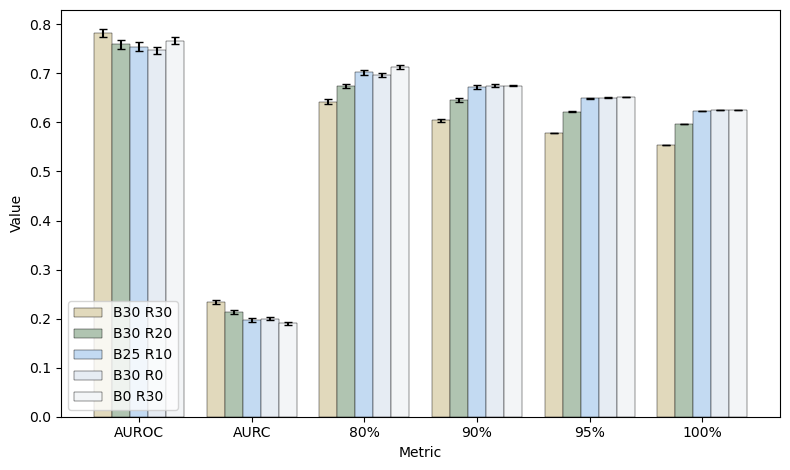

In [23]:
"""
Figure: mean ± std error bars
"""

plot_summary_over_solutions_bars(
    summary_over_solutions,
    show_error_bars=True,
    error_kind="std",
    out_path="Llama_AUROC_AURC_barras",
)


----
# Data for tables  
----

In [26]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd


def build_uq_tables_for_model(
    summary_over_solutions: Dict[str, dict],
    *,
    model_name: str,
    coverages: Tuple[float, ...] = (0.8, 0.9, 0.95, 1.0),
    out_dir: str = ".",
    file_prefix: Optional[str] = None,
    float_fmt: str = "{:.3f}",
) -> Dict[str, object]:
    """
    Build Table 1 and Table 2 for one model from summary_over_solutions, and export:
    1) pandas DataFrame for Table 1 (main results) and Table 2 (calibration stability)
    2) LaTeX table strings compatible with ACM (tabular + booktabs style)
    3) CSV files for appendix material (raw mean, std, var, n)

    Expected input format
    summary_over_solutions[scheme_name] contains:
      auroc_mean_over_solutions: {"n","mean","var","std"}
      aurc_mean_over_solutions:  {"n","mean","var","std"}
      acc_joint_mean_over_solutions: {"n","mean","var","std"}  optional but recommended
      tau_bert_mean_over_solutions: {"n","mean","var","std"}   optional but recommended
      tau_rouge_mean_over_solutions: {"n","mean","var","std"}  optional but recommended
      rejection_acc_mean_over_solutions: {coverage: {"n","mean","var","std"}, ...}

    Returns a dict with keys
      df_table1, df_table2
      latex_table1, latex_table2
      csv_table1_path, csv_table2_path
      csv_raw_path

    Notes
    float_fmt controls how numbers are displayed in formatted columns (mean ± std).
    CSV outputs include both formatted columns and raw mean, std, var, n.
    """

    def _get_stat(block: dict, key: str) -> dict:
        if key not in block:
            return {"n": np.nan, "mean": np.nan, "std": np.nan, "var": np.nan}
        d = block[key]
        return {
            "n": d.get("n", np.nan),
            "mean": d.get("mean", np.nan),
            "std": d.get("std", np.nan),
            "var": d.get("var", np.nan),
        }

    def _fmt_pm(mean: float, std: float) -> str:
        if mean is None or std is None or (np.isnan(mean) or np.isnan(std)):
            return ""
        return f"{float_fmt.format(mean)} ± {float_fmt.format(std)}"

    def _safe_float(x):
        try:
            return float(x)
        except Exception:
            return np.nan

    schemes = list(summary_over_solutions.keys())

    rows_t1 = []
    rows_t2 = []
    rows_raw = []

    for scheme in schemes:
        s = summary_over_solutions[scheme]

        auroc = _get_stat(s, "auroc_mean_over_solutions")
        aurc = _get_stat(s, "aurc_mean_over_solutions")
        accj = _get_stat(s, "acc_joint_mean_over_solutions")
        taub = _get_stat(s, "tau_bert_mean_over_solutions")
        taur = _get_stat(s, "tau_rouge_mean_over_solutions")

        rej = s.get("rejection_acc_mean_over_solutions", {})
        rej_stats = {c: {"n": np.nan, "mean": np.nan, "std": np.nan, "var": np.nan} for c in coverages}
        for c in coverages:
            if c in rej:
                rej_stats[c] = {
                    "n": rej[c].get("n", np.nan),
                    "mean": rej[c].get("mean", np.nan),
                    "std": rej[c].get("std", np.nan),
                    "var": rej[c].get("var", np.nan),
                }

        n_solutions = int(s.get("n_solutions", auroc.get("n", np.nan))) if not np.isnan(auroc.get("n", np.nan)) else s.get("n_solutions", np.nan)

        # Table 1 row (main)
        t1 = {
            "Model": model_name,
            "Scheme": scheme,
            "AUROC (mean ± std)": _fmt_pm(auroc["mean"], auroc["std"]),
            "AURC (mean ± std)": _fmt_pm(aurc["mean"], aurc["std"]),
            **{f"Acc@{int(c*100)} (mean ± std)": _fmt_pm(rej_stats[c]["mean"], rej_stats[c]["std"]) for c in coverages},
            "n": n_solutions,
        }
        rows_t1.append(t1)

        # Table 2 row (calibration and operating point)
        errj_mean = np.nan
        errj_std = np.nan
        if not np.isnan(accj["mean"]):
            errj_mean = 1.0 - accj["mean"]
            errj_std = accj["std"] if not np.isnan(accj["std"]) else np.nan

        t2 = {
            "Model": model_name,
            "Scheme": scheme,
            "τbert (mean ± std)": _fmt_pm(taub["mean"], taub["std"]),
            "τrouge (mean ± std)": _fmt_pm(taur["mean"], taur["std"]),
            "JointAcc (mean ± std)": _fmt_pm(accj["mean"], accj["std"]),
            "JointErr (mean ± std)": _fmt_pm(errj_mean, errj_std) if not np.isnan(errj_mean) else "",
            "n": n_solutions,
        }
        rows_t2.append(t2)

        # Raw row for appendix (wide, numeric)
        raw = {
            "Model": model_name,
            "Scheme": scheme,
            "n_solutions": n_solutions,
            "auroc_mean": _safe_float(auroc["mean"]),
            "auroc_std": _safe_float(auroc["std"]),
            "auroc_var": _safe_float(auroc["var"]),
            "aurc_mean": _safe_float(aurc["mean"]),
            "aurc_std": _safe_float(aurc["std"]),
            "aurc_var": _safe_float(aurc["var"]),
            "acc_joint_mean": _safe_float(accj["mean"]),
            "acc_joint_std": _safe_float(accj["std"]),
            "acc_joint_var": _safe_float(accj["var"]),
            "tau_bert_mean": _safe_float(taub["mean"]),
            "tau_bert_std": _safe_float(taub["std"]),
            "tau_bert_var": _safe_float(taub["var"]),
            "tau_rouge_mean": _safe_float(taur["mean"]),
            "tau_rouge_std": _safe_float(taur["std"]),
            "tau_rouge_var": _safe_float(taur["var"]),
        }
        for c in coverages:
            raw[f"rej_acc_{int(c*100)}_mean"] = _safe_float(rej_stats[c]["mean"])
            raw[f"rej_acc_{int(c*100)}_std"] = _safe_float(rej_stats[c]["std"])
            raw[f"rej_acc_{int(c*100)}_var"] = _safe_float(rej_stats[c]["var"])

        rows_raw.append(raw)

    df_table1 = pd.DataFrame(rows_t1)
    df_table2 = pd.DataFrame(rows_t2)
    df_raw = pd.DataFrame(rows_raw)

    # Sort rows for consistent presentation
    df_table1 = df_table1.sort_values(["Model", "Scheme"]).reset_index(drop=True)
    df_table2 = df_table2.sort_values(["Model", "Scheme"]).reset_index(drop=True)
    df_raw = df_raw.sort_values(["Model", "Scheme"]).reset_index(drop=True)

    # Export CSVs
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    prefix = file_prefix or model_name.lower().replace(" ", "_").replace(".", "").replace("/", "_")
    csv_table1_path = out_path / f"{prefix}_table1_main.csv"
    csv_table2_path = out_path / f"{prefix}_table2_calib.csv"
    csv_raw_path = out_path / f"{prefix}_appendix_raw.csv"

    df_table1.to_csv(csv_table1_path, index=False)
    df_table2.to_csv(csv_table2_path, index=False)
    df_raw.to_csv(csv_raw_path, index=False)

    # LaTeX for ACM: tabular with booktabs style
    def _df_to_latex_acm(df: pd.DataFrame, caption: str, label: str) -> str:
        latex_body = df.to_latex(
            index=False,
            escape=True,
            column_format="l" * df.shape[1],
        )
        # Replace default rules with booktabs rules
        latex_body = latex_body.replace("\\toprule", "\\toprule")
        latex_body = latex_body.replace("\\midrule", "\\midrule")
        latex_body = latex_body.replace("\\bottomrule", "\\bottomrule")

        return (
            "\\begin{table}[t]\n"
            "\\caption{" + caption + "}\n"
            "\\label{" + label + "}\n"
            "\\centering\n"
            "\\small\n"
            + latex_body
            + "\\end{table}\n"
        )

    latex_table1 = _df_to_latex_acm(
        df_table1,
        caption=f"UQ performance summary for {model_name} across threshold schemes (mean ± std over solutions).",
        label=f"tab:uq_main_{prefix}",
    )
    latex_table2 = _df_to_latex_acm(
        df_table2,
        caption=f"Calibration thresholds and joint correctness operating point for {model_name} (mean ± std over solutions).",
        label=f"tab:uq_calib_{prefix}",
    )

    return {
        "df_table1": df_table1,
        "df_table2": df_table2,
        "latex_table1": latex_table1,
        "latex_table2": latex_table2,
        "csv_table1_path": str(csv_table1_path),
        "csv_table2_path": str(csv_table2_path),
        "csv_raw_path": str(csv_raw_path),
    }


In [28]:
out = build_uq_tables_for_model(
    summary_over_solutions,
    model_name="Llama 3.1 8B",
    out_dir="tables",
)

df1 = out["df_table1"]
df2 = out["df_table2"]

print(out["latex_table1"])
print(out["latex_table2"])

print("Saved:", out["csv_table1_path"], out["csv_table2_path"], out["csv_raw_path"])


\begin{table}[t]
\caption{UQ performance summary for Llama 3.1 8B across threshold schemes (mean ± std over solutions).}
\label{tab:uq_main_llama_31_8b}
\centering
\small
\begin{tabular}{lllllllll}
\toprule
Model & Scheme & AUROC (mean ± std) & AURC (mean ± std) & Acc@80 (mean ± std) & Acc@90 (mean ± std) & Acc@95 (mean ± std) & Acc@100 (mean ± std) & n \\
\midrule
Llama 3.1 8B & B0 R30 & 0.767 ± 0.007 & 0.190 ± 0.003 & 0.713 ± 0.005 & 0.675 ± 0.001 & 0.652 ± 0.001 & 0.626 ± 0.000 & 11 \\
Llama 3.1 8B & B25 R10 & 0.755 ± 0.009 & 0.198 ± 0.004 & 0.702 ± 0.005 & 0.673 ± 0.004 & 0.649 ± 0.001 & 0.623 ± 0.000 & 11 \\
Llama 3.1 8B & B30 R0 & 0.747 ± 0.007 & 0.200 ± 0.003 & 0.697 ± 0.004 & 0.675 ± 0.003 & 0.651 ± 0.001 & 0.625 ± 0.000 & 11 \\
Llama 3.1 8B & B30 R20 & 0.759 ± 0.009 & 0.213 ± 0.004 & 0.674 ± 0.005 & 0.646 ± 0.004 & 0.622 ± 0.001 & 0.597 ± 0.000 & 11 \\
Llama 3.1 8B & B30 R30 & 0.782 ± 0.008 & 0.233 ± 0.004 & 0.642 ± 0.005 & 0.604 ± 0.003 & 0.578 ± 0.000 & 0.553 ± 0.000 & 11 \\

---
# Statistics on early termination
---

In [29]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class EarlyStopStats:
    """
    Per run (one seed directory) statistics extracted from progress.csv.

    Key ideas
    - "stop_gen" is the last generation present in progress.csv (the run ended there).
    - We report final and best hypervolume statistics, plus when improvements happened.
    - If earlystop_no_improve is present, we also report the final counter value.
    """
    seed_dir: str
    stop_gen: int
    final_hv: float
    best_hv: float
    gen_best_hv: int
    final_hv_smooth: float
    best_hv_smooth: float
    gen_best_hv_smooth: int
    final_no_improve: Optional[int]
    first_gen_hv: float
    hv_gain_abs: float
    hv_gain_rel: float
    n_gens: int


def _safe_float(x) -> float:
    try:
        return float(x)
    except Exception:
        return float("nan")


def summarize_one_progress_csv(progress_csv: Path) -> EarlyStopStats:
    """
    Load one progress.csv and compute early stopping relevant statistics.

    Expected columns (minimal)
    - gen
    - hv
    Optional columns
    - hv_smooth
    - hv_best_smooth
    - earlystop_no_improve

    Returns
    - EarlyStopStats for this run

    Raises
    - FileNotFoundError if progress_csv does not exist
    - ValueError if required columns are missing
    """
    if not progress_csv.exists():
        raise FileNotFoundError(f"Missing progress.csv: {progress_csv}")

    df = pd.read_csv(progress_csv)
    if "gen" not in df.columns or "hv" not in df.columns:
        raise ValueError(f"progress.csv must include columns gen and hv: {progress_csv}")

    df = df.copy()
    df["gen"] = pd.to_numeric(df["gen"], errors="coerce")
    df["hv"] = pd.to_numeric(df["hv"], errors="coerce")
    df = df.dropna(subset=["gen"]).sort_values("gen")

    if df.empty:
        raise ValueError(f"progress.csv has no valid rows after parsing: {progress_csv}")

    stop_gen = int(df["gen"].iloc[-1])
    n_gens = int(df.shape[0])

    first_hv = _safe_float(df["hv"].iloc[0])
    final_hv = _safe_float(df["hv"].iloc[-1])

    # Best hv and when
    idx_best_hv = int(df["hv"].idxmax())
    best_hv = _safe_float(df.loc[idx_best_hv, "hv"])
    gen_best_hv = int(df.loc[idx_best_hv, "gen"])

    # Smoothed hv stats if present, else mirror hv
    if "hv_smooth" in df.columns:
        df["hv_smooth"] = pd.to_numeric(df["hv_smooth"], errors="coerce")
        hv_smooth_series = df["hv_smooth"]
    else:
        hv_smooth_series = df["hv"]

    final_hv_smooth = _safe_float(hv_smooth_series.iloc[-1])
    idx_best_hv_smooth = int(hv_smooth_series.idxmax())
    best_hv_smooth = _safe_float(hv_smooth_series.loc[idx_best_hv_smooth])
    gen_best_hv_smooth = int(df.loc[idx_best_hv_smooth, "gen"])

    # Early stop counter if present
    final_no_improve: Optional[int] = None
    if "earlystop_no_improve" in df.columns:
        last_val = df["earlystop_no_improve"].iloc[-1]
        try:
            final_no_improve = int(last_val)
        except Exception:
            final_no_improve = None

    hv_gain_abs = final_hv - first_hv
    hv_gain_rel = (hv_gain_abs / abs(first_hv)) if np.isfinite(first_hv) and first_hv != 0 else float("nan")

    return EarlyStopStats(
        seed_dir=str(progress_csv.parent.name),
        stop_gen=stop_gen,
        final_hv=final_hv,
        best_hv=best_hv,
        gen_best_hv=gen_best_hv,
        final_hv_smooth=final_hv_smooth,
        best_hv_smooth=best_hv_smooth,
        gen_best_hv_smooth=gen_best_hv_smooth,
        final_no_improve=final_no_improve,
        first_gen_hv=first_hv,
        hv_gain_abs=hv_gain_abs,
        hv_gain_rel=hv_gain_rel,
        n_gens=n_gens,
    )


def summarize_early_stopping_across_seeds(
    base_dir: str | Path,
    *,
    seed_glob: str = "seed_*",
    progress_name: str = "progress.csv",
    require_progress: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Traverse seed directories under base_dir and compute early stopping statistics.

    Parameters
    base_dir
        Root folder that contains seed directories like seed_001, seed_002, ...
    seed_glob
        Glob pattern for seed directories.
    progress_name
        Filename to read inside each seed directory.
    require_progress
        If True, raise if any seed directory is missing progress.csv.
        If False, skip missing files.

    Returns
    per_run_df
        One row per seed directory found with progress.csv.
    summary_df
        Aggregated statistics across seeds (mean, std, min, max) for key metrics.

    Notes
    - stop_gen is used as a proxy for the generation at which early stopping terminated the run.
    - If you use a fixed generation budget with no early stopping, stop_gen will equal that budget.
    """
    base_dir = Path(base_dir)
    seed_dirs = sorted([p for p in base_dir.glob(seed_glob) if p.is_dir()])

    rows = []
    missing = []
    for sd in seed_dirs:
        progress_csv = sd / progress_name
        if not progress_csv.exists():
            if require_progress:
                missing.append(str(progress_csv))
            continue
        stats = summarize_one_progress_csv(progress_csv)
        rows.append(stats.__dict__)

    if missing:
        raise FileNotFoundError("Missing progress.csv files:\n" + "\n".join(missing))

    per_run_df = pd.DataFrame(rows)
    if per_run_df.empty:
        summary_df = pd.DataFrame()
        return per_run_df, summary_df

    # Compute aggregated summary across seeds
    numeric_cols = [
        "stop_gen",
        "final_hv",
        "best_hv",
        "gen_best_hv",
        "final_hv_smooth",
        "best_hv_smooth",
        "gen_best_hv_smooth",
        "first_gen_hv",
        "hv_gain_abs",
        "hv_gain_rel",
        "n_gens",
    ]
    existing_numeric_cols = [c for c in numeric_cols if c in per_run_df.columns]

    summary = []
    for c in existing_numeric_cols:
        s = pd.to_numeric(per_run_df[c], errors="coerce")
        summary.append(
            {
                "metric": c,
                "mean": float(np.nanmean(s)),
                "std": float(np.nanstd(s, ddof=1)) if s.notna().sum() > 1 else float("nan"),
                "min": float(np.nanmin(s)),
                "max": float(np.nanmax(s)),
                "n": int(s.notna().sum()),
            }
        )

    summary_df = pd.DataFrame(summary).sort_values("metric").reset_index(drop=True)

    # Helpful ordering
    per_run_df = per_run_df.sort_values("seed_dir").reset_index(drop=True)
    return per_run_df, summary_df




In [30]:
# Early stopping

per_run, summary = summarize_early_stopping_across_seeds(all_seeds_root_dir)

print("\nPer run (one row per seed):")
print(per_run.to_string(index=False))

print("\nAggregated summary across seeds:")
print(summary.to_string(index=False))



Per run (one row per seed):
seed_dir  stop_gen  final_hv  best_hv  gen_best_hv  final_hv_smooth  best_hv_smooth  gen_best_hv_smooth  final_no_improve  first_gen_hv  hv_gain_abs  hv_gain_rel  n_gens
seed_001        22  0.370795 0.370795           17         0.370795        0.370795                  21                 5      0.352920     0.017875     0.050649      22
seed_002        16  0.389042 0.389042           16         0.388841        0.388841                  16                 5      0.376664     0.012377     0.032860      16
seed_003        22  0.457546 0.457546           18         0.457546        0.457546                  22                 5      0.426710     0.030836     0.072266      22
seed_008        13  0.372210 0.372210           12         0.372117        0.372117                  13                 5      0.369056     0.003154     0.008546      13
seed_009        19  0.449953 0.449953           17         0.449953        0.449953                  19                 5